# Import data

In [1]:
!pip install fathomnet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.4/300.4 kB 30.9 MB/s eta 0:00:00


In [2]:
from fathomnet.api import boundingboxes

print("Fetching global concept counts from FathomNet...")

# 1. Fetch counts for every concept in the database
# This returns a list of ByConceptCount objects (concept, count)
all_counts = boundingboxes.count_total_by_concept()

# 2. Sort the concepts descending by their count
all_counts.sort(key=lambda x: x.count, reverse=True)

# 3. Filter out generic, non-biological, or broad taxonomic categories
# You want distinct species/genera for a classification assignment
exclude_list = [
    "equipment", "unknown", "marine organism", "particulate",
    "trash", "debris", "rov", "animalia", "ocean floor", "background"
]

top_10_species = []

print("\n--- Top 10 Most Populated Marine Species ---")
for item in all_counts:
    # Ignore case for safe matching
    if item.concept.lower() not in exclude_list:
        top_10_species.append(item.concept)
        print(f"{len(top_10_species)}. {item.concept} (Annotations: {item.count})")

    # Stop once we have our 10 classes
    if len(top_10_species) == 10:
        break

Fetching global concept counts from FathomNet...

--- Top 10 Most Populated Marine Species ---
1. Lutjanus campechanus (Annotations: 151292)
2. sea fan (Annotations: 51480)
3. Stenotomus caprinus (Annotations: 26775)
4. Rhomboplites aurorubens (Annotations: 25825)
5. Strongylocentrotus fragilis (Annotations: 23061)
6. bony fish (Annotations: 21664)
7. Ptereleotris (Annotations: 21131)
8. sponge (Annotations: 21107)
9. Pagrus pagrus (Annotations: 17028)
10. Chromis (Annotations: 15769)


In [3]:
top_10_species

['Lutjanus campechanus',
 'sea fan',
 'Stenotomus caprinus',
 'Rhomboplites aurorubens',
 'Strongylocentrotus fragilis',
 'bony fish',
 'Ptereleotris',
 'sponge',
 'Pagrus pagrus',
 'Chromis']

In [34]:
import os
import requests
import pandas as pd
import numpy as np
import tensorflow as tf
from fathomnet.api import images
from concurrent.futures import ThreadPoolExecutor

# 4.6 Reproducibility: Seed consistently across the codebase [cite: 59]
np.random.seed(42)
tf.random.set_seed(42)

# Define a subset of species for this example
target_species = [
    'Lutjanus campechanus',
    'sea fan',
    'Stenotomus caprinus',
    'Rhomboplites aurorubens',
    'Strongylocentrotus fragilis',
    'bony fish',
    'Ptereleotris',
    'sponge',
    'Pagrus pagrus',
    'Chromis'
    ]

def fetch_fathomnet_metadata(species_list, max_images_per_class=100):
    """Fetches image metadata from FathomNet and returns a Pandas DataFrame."""
    data = []
    for species in species_list:
        print(f"Fetching metadata for {species}...")
        records = images.find_by_concept(species)

        # Limit the number of images per class for balanced training/testing
        for rec in records[:max_images_per_class]:
            data.append({
                "species": species,
                "uuid": rec.uuid,
                "url": rec.url,
                "local_path": f"dataset/{species}/{rec.uuid}.jpg"
            })
    return pd.DataFrame(data)

df = fetch_fathomnet_metadata(target_species, max_images_per_class=500)

print(f"\nTotal images successfully indexed: {len(df)}")
print(df['species'].value_counts())

Fetching metadata for Lutjanus campechanus...
Fetching metadata for sea fan...
Fetching metadata for Stenotomus caprinus...
Fetching metadata for Rhomboplites aurorubens...
Fetching metadata for Strongylocentrotus fragilis...
Fetching metadata for bony fish...
Fetching metadata for Ptereleotris...
Fetching metadata for sponge...
Fetching metadata for Pagrus pagrus...
Fetching metadata for Chromis...

Total images successfully indexed: 5000
species
Lutjanus campechanus           500
sea fan                        500
Stenotomus caprinus            500
Rhomboplites aurorubens        500
Strongylocentrotus fragilis    500
bony fish                      500
Ptereleotris                   500
sponge                         500
Pagrus pagrus                  500
Chromis                        500
Name: count, dtype: int64


In [35]:
def download_image(row):
    """Downloads an image from a URL to a local path."""
    os.makedirs(os.path.dirname(row['local_path']), exist_ok=True)
    if not os.path.exists(row['local_path']):
        try:
            response = requests.get(row['url'], timeout=10)
            if response.status_code == 200:
                with open(row['local_path'], 'wb') as f:
                    f.write(response.content)
        except Exception as e:
            pass # Handle broken links silently for this script

print("Downloading images...")
# Use ThreadPoolExecutor for faster concurrent downloading
with ThreadPoolExecutor(max_workers=10) as executor:
    executor.map(download_image, df.to_dict('records'))

# Filter out any rows where the image failed to download
df = df[df['local_path'].apply(os.path.exists)]

# Processing

In [36]:
from sklearn.model_selection import train_test_split

# 1. Filter out any rows where the image failed to download (safety check)
df = df[df['local_path'].apply(os.path.exists)].copy()
print(f"Total downloaded images verified on disk: {len(df)}")

# 2. Define the OOD split based on our previous setup
known_classes = [
    'Lutjanus campechanus', 'sea fan', 'Stenotomus caprinus',
    'Rhomboplites aurorubens', 'Strongylocentrotus fragilis',
    'bony fish', 'Ptereleotris', 'sponge'
]
ood_classes = ['Pagrus pagrus', 'Chromis']

# 3. Split DataFrames
df_known = df[df['species'].isin(known_classes)].copy()
df_ood = df[df['species'].isin(ood_classes)].copy()

# 4. Map categorical string labels to integer IDs (0 to 7) for Known Classes
species_to_id = {name: idx for idx, name in enumerate(known_classes)}
df_known['label_id'] = df_known['species'].map(species_to_id)

# 5. Split known data into 80% Training and 20% Validation
# Using stratify ensures each class is represented equally in both sets
df_train, df_val = train_test_split(
    df_known,
    test_size=0.2,
    random_state=42,
    stratify=df_known['label_id']
)

print(f"Training Samples: {len(df_train)}")
print(f"Validation Samples: {len(df_val)}")
print(f"OOD (Unknown) Samples: {len(df_ood)}")

Total downloaded images verified on disk: 5000
Training Samples: 3200
Validation Samples: 800
OOD (Unknown) Samples: 1000


In [38]:
IMAGE_SIZE = (224, 224)
BATCH_SIZE = 32

def process_path(file_path, label):
    """Reads, decodes, resizes, and normalizes an image."""
    img = tf.io.read_file(file_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, IMAGE_SIZE)
    img = img / 255.0 # Normalize to [0,1]
    return img, label

print("Constructing tf.data.Dataset pipelines...")

# --- Training Dataset ---
train_ds = tf.data.Dataset.from_tensor_slices((df_train['local_path'].values, df_train['label_id'].values))
train_ds = train_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
train_ds = train_ds.shuffle(buffer_size=len(df_train), seed=42).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- Validation Dataset ---
val_ds = tf.data.Dataset.from_tensor_slices((df_val['local_path'].values, df_val['label_id'].values))
val_ds = val_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
val_ds = val_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

# --- OOD Dataset ---
# Labels don't matter for OOD evaluation, so we assign a dummy label (-1)
ood_labels = np.full(len(df_ood), -1)
ood_ds = tf.data.Dataset.from_tensor_slices((df_ood['local_path'].values, ood_labels))
ood_ds = ood_ds.map(process_path, num_parallel_calls=tf.data.AUTOTUNE)
ood_ds = ood_ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

print("Pipelines ready for training!")

Constructing tf.data.Dataset pipelines...
Pipelines ready for training!


# CNN

In [40]:
from tensorflow.keras import layers, models, optimizers

def build_model_a(learning_rate):
    """Builds a 3-block CNN from scratch."""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Classification Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Helps prevent overfitting
        layers.Dense(8, activation='softmax') # 8 units for our 8 Known Classes
    ])

    model.compile(
        optimizer=optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

EPOCHS = 3 # Adjust based on Colab time constraints

# Configuration 1: Standard Learning Rate
print("\n--- Training Model A: Config 1 (LR=0.001) ---")
model_a_config1 = build_model_a(learning_rate=0.001)
history_a1 = model_a_config1.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

# Configuration 2: Lower Learning Rate
print("\n--- Training Model A: Config 2 (LR=0.0001) ---")
model_a_config2 = build_model_a(learning_rate=0.0001)
history_a2 = model_a_config2.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)


--- Training Model A: Config 1 (LR=0.001) ---
Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 257s 893ms/step - accuracy: 0.6769 - loss: 0.9025 - val_accuracy: 0.8775 - val_loss: 0.3472
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 196s 471ms/step - accuracy: 0.8616 - loss: 0.3679 - val_accuracy: 0.8988 - val_loss: 0.2500
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 189s 388ms/step - accuracy: 0.8969 - loss: 0.2914 - val_accuracy: 0.9062 - val_loss: 0.2336

--- Training Model A: Config 2 (LR=0.0001) ---
Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 207s 477ms/step - accuracy: 0.5831 - loss: 1.1548 - val_accuracy: 0.8300 - val_loss: 0.5478
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 190s 386ms/step - accuracy: 0.8003 - loss: 0.5956 - val_accuracy: 0.8675 - val_loss: 0.4097
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 190s 385ms/step - accuracy: 0.8431 - loss: 0.4525 - val_accuracy: 0.8750 - val_loss: 0.3468


#

# Transfer learning

In [41]:
from tensorflow.keras.applications import MobileNetV2

print("\n--- Constructing Model B (MobileNetV2) ---")

# Load the pretrained backbone
base_model = MobileNetV2(input_shape=(224, 224, 3), include_top=False, weights='imagenet')

# Add our custom classification head for the 8 Known Classes
inputs = tf.keras.Input(shape=(224, 224, 3))
x = base_model(inputs, training=False) # Keep BatchNormalization in inference mode
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(8, activation='softmax')(x)
model_b = tf.keras.Model(inputs, outputs)

# ---------------------------------------------------------
# Strategy 1: Feature Extraction (Backbone completely frozen)
# ---------------------------------------------------------
print("\n--- Strategy 1: Feature Extraction ---")
base_model.trainable = False

model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

# Only training for 3 epochs to save Colab resources
history_b_feat = model_b.fit(train_ds, validation_data=val_ds, epochs=3)

# ---------------------------------------------------------
# Strategy 2: Partial Fine-Tuning (Top layers unfrozen)
# ---------------------------------------------------------
print("\n--- Strategy 2: Partial Fine-Tuning ---")
base_model.trainable = True

# Freeze the bottom 100 layers, unfreeze the rest
for layer in base_model.layers[:100]:
    layer.trainable = False

# Recompile with a lower learning rate!
model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-4),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_b_part = model_b.fit(train_ds, validation_data=val_ds, epochs=3)

# ---------------------------------------------------------
# Strategy 3: Full Fine-Tuning (All layers unfrozen)
# ---------------------------------------------------------
print("\n--- Strategy 3: Full Fine-Tuning ---")
base_model.trainable = True

# Recompile with a VERY low learning rate to prevent catastrophic forgetting
model_b.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
                loss='sparse_categorical_crossentropy',
                metrics=['accuracy'])

history_b_full = model_b.fit(train_ds, validation_data=val_ds, epochs=3)


--- Constructing Model B (MobileNetV2) ---
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

--- Strategy 1: Feature Extraction ---
Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 216s 461ms/step - accuracy: 0.7706 - loss: 0.6623 - val_accuracy: 0.9075 - val_loss: 0.2907
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 195s 448ms/step - accuracy: 0.9094 - loss: 0.2733 - val_accuracy: 0.9025 - val_loss: 0.2536
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 187s 367ms/step - accuracy: 0.9253 - loss: 0.2182 - val_accuracy: 0.9262 - val_loss: 0.1974

--- Strategy 2: Partial Fine-Tuning ---
Epoch 1/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 217s 420ms/step - accuracy: 0.9128 - loss: 0.2538 - val_accuracy: 0.9100 - val_loss: 0.2779
Epoch 2/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 254s 460ms/step - accuracy: 0.9722 - loss: 0.0833 - val_accuracy: 0.9337 - val_loss: 0.2126
Epoch 3/3
100/100 ━━━━━━━━━━━━━━━━━━━━ 198s 463ms/step - accuracy: 0.9869 - loss: 0.0437 - val_accuracy: 0.9337 - val_loss: 0.2167

--- Strategy 3: Full Fine-Tuning ---
Ep

# Evaluation and visualization

--- Evaluating Model A (Custom CNN) ---


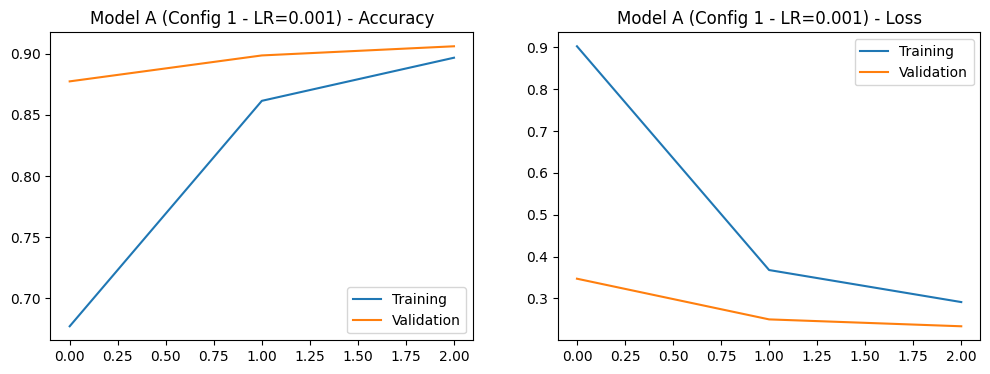


--- Classification Report (Model A) ---
                             precision    recall  f1-score   support

       Lutjanus campechanus       1.00      0.98      0.99       100
                    sea fan       0.75      0.83      0.79       100
        Stenotomus caprinus       1.00      1.00      1.00       100
    Rhomboplites aurorubens       0.98      1.00      0.99       100
Strongylocentrotus fragilis       0.86      0.97      0.91       100
                  bony fish       0.83      0.60      0.70       100
               Ptereleotris       1.00      1.00      1.00       100
                     sponge       0.84      0.87      0.85       100

                   accuracy                           0.91       800
                  macro avg       0.91      0.91      0.90       800
               weighted avg       0.91      0.91      0.90       800



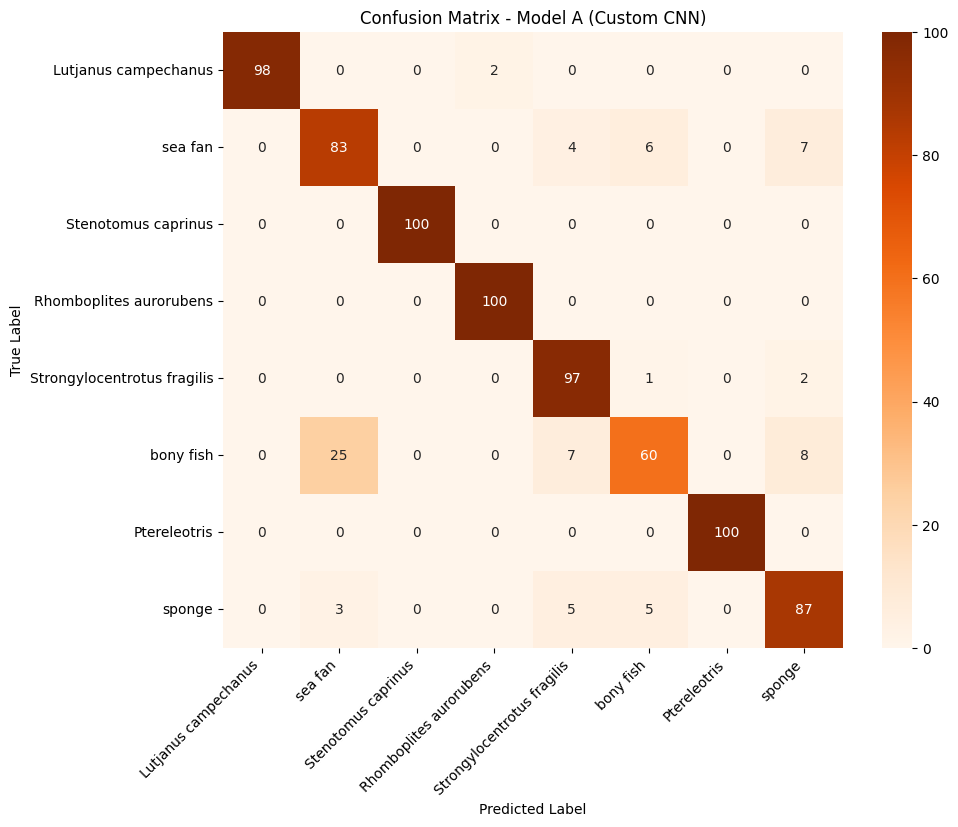

In [46]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Select which Model A configuration to evaluate (we'll use config 1 here)
target_model_a = model_a_config1

print("--- Evaluating Model A (Custom CNN) ---")

# 1. Plot Training and Validation Curves
# (Assuming plot_history was defined in the Model B section; if not, you can redefine it here)
plot_history(history_a1, "Model A (Config 1 - LR=0.001)")

# 2. Extract true labels and predictions from the Validation set
y_true_a = []
y_pred_probs_a = []

for images, labels in val_ds:
    y_true_a.extend(labels.numpy())
    preds = target_model_a.predict(images, verbose=0)
    y_pred_probs_a.extend(preds)

y_true_a = np.array(y_true_a)
y_pred_probs_a = np.array(y_pred_probs_a)
y_pred_a = np.argmax(y_pred_probs_a, axis=1)

# 3. Print Classification Report
print("\n--- Classification Report (Model A) ---")
print(classification_report(y_true_a, y_pred_a, target_names=known_classes, zero_division=0))

# 4. Plot Confusion Matrix Heatmap
cm_a = confusion_matrix(y_true_a, y_pred_a)
plt.figure(figsize=(10, 8))
# Using a different color ('Oranges') to visually distinguish from Model B in your report
sns.heatmap(cm_a, annot=True, fmt='d', cmap='Oranges',
            xticklabels=known_classes, yticklabels=known_classes)
plt.title('Confusion Matrix - Model A (Custom CNN)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.show()

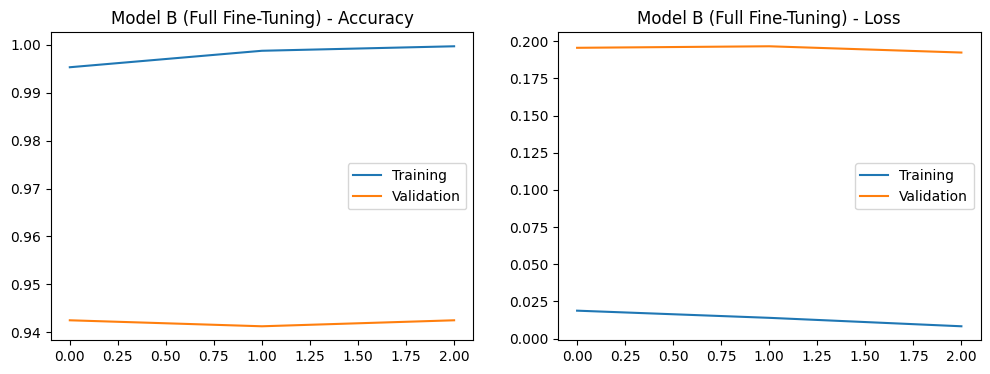


--- Classification Report ---
                             precision    recall  f1-score   support

       Lutjanus campechanus       1.00      0.99      0.99       100
                    sea fan       0.87      0.83      0.85       100
        Stenotomus caprinus       1.00      1.00      1.00       100
    Rhomboplites aurorubens       0.99      1.00      1.00       100
Strongylocentrotus fragilis       0.99      0.95      0.97       100
                  bony fish       0.84      0.84      0.84       100
               Ptereleotris       1.00      1.00      1.00       100
                     sponge       0.85      0.93      0.89       100

                   accuracy                           0.94       800
                  macro avg       0.94      0.94      0.94       800
               weighted avg       0.94      0.94      0.94       800



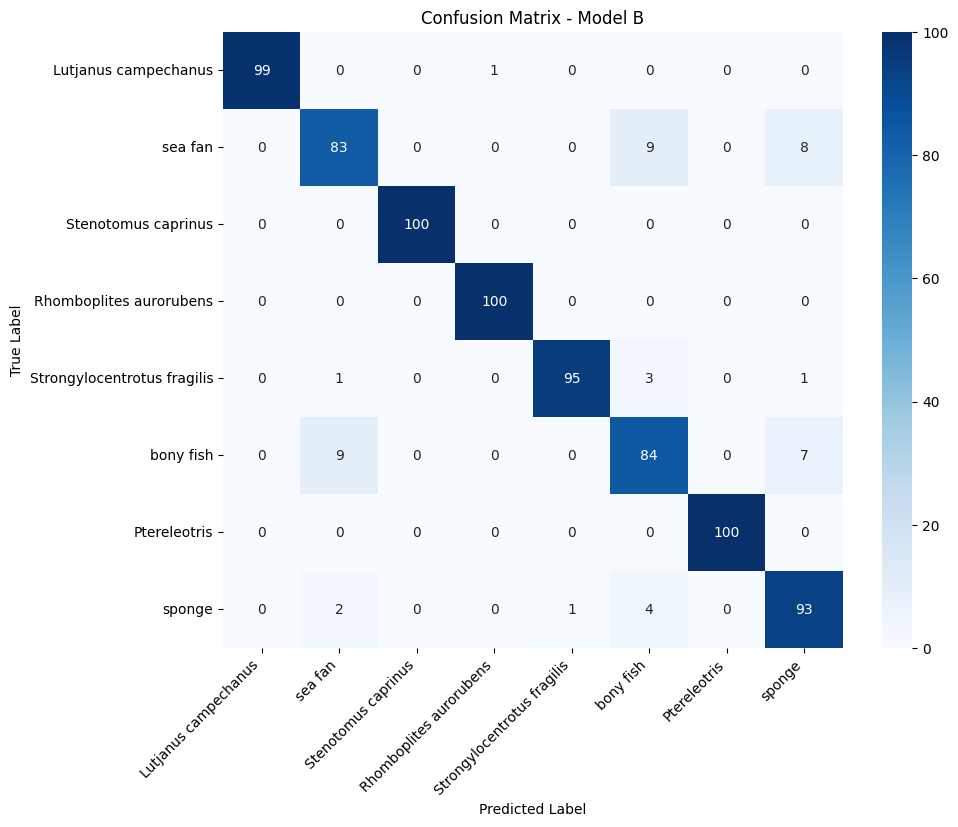

In [42]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

def plot_history(history, title):
    """Plots accuracy and loss curves."""
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']

    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training')
    plt.plot(val_acc, label='Validation')
    plt.title(f'{title} - Accuracy')
    plt.legend()

    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training')
    plt.plot(val_loss, label='Validation')
    plt.title(f'{title} - Loss')
    plt.legend()
    plt.show()

# 1. Plot curves for the Full Fine-Tuning run
plot_history(history_b_full, "Model B (Full Fine-Tuning)")

# 2. Extract true labels and predictions from the Validation set
y_true = []
y_pred_probs = []

# Iterate through the tf.data.Dataset to get predictions
for images, labels in val_ds:
    y_true.extend(labels.numpy())
    preds = model_b.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# 3. Print Classification Report (Accuracy, Precision, Recall, Macro F1)
print("\n--- Classification Report ---")
print(classification_report(y_true, y_pred, target_names=known_classes))

# 4. Plot Confusion Matrix Heatmap
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=known_classes, yticklabels=known_classes)
plt.title('Confusion Matrix - Model B')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.show()

# OOD detection

In [47]:
from sklearn.metrics import precision_score, recall_score

print("\n--- Out-of-Distribution (OOD) Detection Evaluation (Model A) ---")

# 1. Get max probabilities for In-Distribution (Known Validation Data)
in_max_probs_a = np.max(y_pred_probs_a, axis=1)
in_labels_a = np.zeros(len(in_max_probs_a)) # 0 = Known

# 2. Get max probabilities for Out-of-Distribution (Unknown Data)
ood_probs_a = []
for images, _ in ood_ds:
    preds = target_model_a.predict(images, verbose=0)
    ood_probs_a.extend(preds)

ood_max_probs_a = np.max(np.array(ood_probs_a), axis=1)
ood_labels_a = np.ones(len(ood_max_probs_a)) # 1 = Unknown

# 3. Combine and apply our threshold
all_max_probs_a = np.concatenate([in_max_probs_a, ood_max_probs_a])
true_ood_labels_a = np.concatenate([in_labels_a, ood_labels_a])

# Threshold: If the model's top confidence is less than 65%, flag it as "Unknown" (1)
THRESHOLD = 0.65
pred_ood_labels_a = (all_max_probs_a < THRESHOLD).astype(int)

# 4. Calculate Precision and Recall for OOD Detection
ood_precision_a = precision_score(true_ood_labels_a, pred_ood_labels_a, zero_division=0)
ood_recall_a = recall_score(true_ood_labels_a, pred_ood_labels_a, zero_division=0)

print(f"Threshold Set: {THRESHOLD}")
print(f"OOD Detection Precision: {ood_precision_a:.4f}")
print(f"OOD Detection Recall: {ood_recall_a:.4f}")


--- Out-of-Distribution (OOD) Detection Evaluation (Model A) ---
Threshold Set: 0.65
OOD Detection Precision: 0.6711
OOD Detection Recall: 0.1510


In [43]:
from sklearn.metrics import precision_score, recall_score

print("\n--- Out-of-Distribution (OOD) Detection Evaluation ---")

# 1. Get max probabilities for In-Distribution (Known Validation Data)
in_max_probs = np.max(y_pred_probs, axis=1)
in_labels = np.zeros(len(in_max_probs)) # 0 = Known

# 2. Get max probabilities for Out-of-Distribution (Unknown Data)
ood_probs = []
for images, _ in ood_ds:
    preds = model_b.predict(images, verbose=0)
    ood_probs.extend(preds)

ood_max_probs = np.max(np.array(ood_probs), axis=1)
ood_labels = np.ones(len(ood_max_probs)) # 1 = Unknown

# 3. Combine and apply our threshold
all_max_probs = np.concatenate([in_max_probs, ood_max_probs])
true_ood_labels = np.concatenate([in_labels, ood_labels])

# Threshold: If the model's top confidence is less than 65%, flag it as "Unknown" (1)
THRESHOLD = 0.65
pred_ood_labels = (all_max_probs < THRESHOLD).astype(int)

# 4. Calculate Precision and Recall for OOD Detection
ood_precision = precision_score(true_ood_labels, pred_ood_labels, zero_division=0)
ood_recall = recall_score(true_ood_labels, pred_ood_labels, zero_division=0)

print(f"Threshold Set: {THRESHOLD}")
print(f"OOD Detection Precision: {ood_precision:.4f}")
print(f"OOD Detection Recall: {ood_recall:.4f}")


--- Out-of-Distribution (OOD) Detection Evaluation ---
Threshold Set: 0.65
OOD Detection Precision: 0.9537
OOD Detection Recall: 0.5360


# Exporting

In [44]:
import os
from google.colab import drive

print("--- Mounting Google Drive ---")
# This will prompt you to log in and grant Colab access to your Drive
drive.mount('/content/drive')

# Create a dedicated folder for your CIE 555 Assignment in your Drive
SAVE_DIR = '/content/drive/MyDrive/CIE555_Assignment'
os.makedirs(SAVE_DIR, exist_ok=True)
print(f"Save directory ready at: {SAVE_DIR}")

# 1. Save Model A (From Scratch)
# Saving the Keras format (.keras) is the modern standard in TensorFlow
print("\n--- Saving Model A configurations ---")
model_a_config1.save(os.path.join(SAVE_DIR, 'model_a_config1.keras'))
model_a_config2.save(os.path.join(SAVE_DIR, 'model_a_config2.keras'))
print("Model A saved successfully.")

# 2. Save Model B (Transfer Learning)
# We save the final state of Model B (which includes the full fine-tuning)
print("\n--- Saving Model B (Transfer Learning) ---")
model_b.save(os.path.join(SAVE_DIR, 'model_b_finetuned.keras'))
print("Model B saved successfully.")

# 3. Save the Dataset Metadata
# Saving your Pandas DataFrame so you don't have to re-fetch the API data later
print("\n--- Saving Dataset Metadata ---")
df.to_csv(os.path.join(SAVE_DIR, 'fathomnet_dataset_metadata.csv'), index=False)
print("Metadata CSV saved successfully.")

# 4. Generate and Save requirements.txt (Requirement 4.6)
print("\n--- Generating requirements.txt ---")

--- Mounting Google Drive ---
Mounted at /content/drive
Save directory ready at: /content/drive/MyDrive/CIE555_Assignment

--- Saving Model A configurations ---
Model A saved successfully.

--- Saving Model B (Transfer Learning) ---
Model B saved successfully.

--- Saving Dataset Metadata ---
Metadata CSV saved successfully.

--- Generating requirements.txt ---


In [45]:
!pip freeze > /content/drive/MyDrive/CIE555_Assignment/requirements.txt